In [3]:
import casadi as cas
import numpy as np
import matplotlib.pyplot as plt
from albatross import Albatross

This block initialises the optimisation problem using the CasADI python API. 

N represents the granularity of the simulation. This is used then to initialies a 4-dimensional state space including the altitude of the bird trajectory (h) and the 3-dimensional velocities (u, v, w). Furthermore, the control variables are created which include the bank angle (mu) and the coefficient of lift (cl). 

The time step must also be included as an optimisation parameter as the optimisation software will adapt a suitable dt for the simulation.

The optimisation objective to be minimised is chosen to the be the wind shear reference strength (V_ref). The efficiency of a gliding flight strategy can be seen as the minimum amount of wind strength required to sustain the same altitude; thus a lower V_ref would mean a more efficient flight path.

Finally the Albatross class is initialised, which is a container for the parameters of the albatross model used in this simulation. This data, which includes e.g mass, wing span, drag coefficients, is taken from Sachs (2005).

In [4]:
opti = cas.Opti()

# Granularity
N = 64

# Spatial coordinate
h = opti.variable(N)    # altitude above sea-level 

# Inertial (ground-frame) velocities
u = opti.variable(N)    # x-direction 
v = opti.variable(N)    # y-direction
w = opti.variable(N)    # z-direction

# Control variables
mu = opti.variable(N)   # Bank angle
cl = opti.variable(N)   # Coefficient of lift

# Minimisation variable
V_ref = opti.variable(1)    # Reference wind speed - determines the wind shear strength in simulation.

# Time step
dt = opti.variable(1)

# Initialise container class for bird attributes.
bird = Albatross()


The wind-speed is simulated using an exponential model, wherein the values for the reference altitude (h_ref) and exponential parameter (p) are taken from Sachs (2005). The wind-speed is then simulated in the negative x-direction (hence the negative sign).

In [5]:
# Windspeed (wind blows in -x direction)
h_ref = 10
p = 0.143
V_w = V_ref * (h/h_ref)**p

The wind-shear gradient is graphed here:

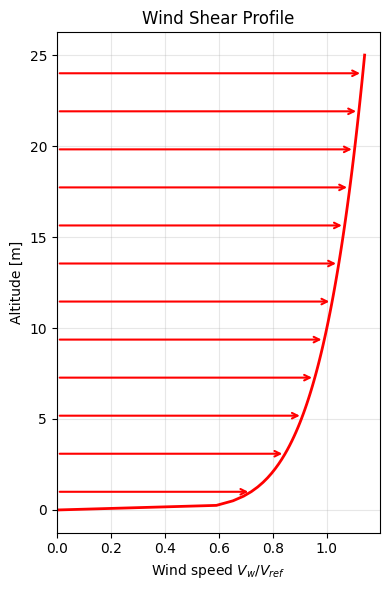

In [6]:
h_shear = np.linspace(0, 25, 100)
V_w_shear = (h_shear / h_ref)**p

fig, ax = plt.subplots(figsize=(4, 6))
ax.plot(V_w_shear, h_shear, lw=2, color='red')
n_arrows = 12
h_arrows = np.linspace(1, 24, n_arrows)
V_arrows = (h_arrows / h_ref)**p
for ha, va in zip(h_arrows, V_arrows):
    ax.annotate('', xy=(va, ha), xytext=(0, ha),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

ax.set_xlabel(r'Wind speed $V_w / V_{ref}$')
ax.set_ylabel('Altitude [m]')
ax.set_title('Wind Shear Profile')
ax.set_xlim(0, None)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The aerodynamic forces are not based on the inertial speeds, which are relative to the ground, but rather the airspeed. The airspeed then includes the windspeed as an extra drag force. 

The airspeed is also used to calculate the final two flight angles; the flight path angle(gamma) and the heading angle (xi).

The flight path angle is the angle of the airpseed in reference to the horizon and determines if you are climbing (+) or descending (-).

The heading angle describe the horizontal movement in reference to the coordinate system; if you are yawing right (+) or left(-). 

In [7]:
# Airspeed
V_a = cas.sqrt((u + V_w)**2 + v**2 + w**2) 

# Resulting flight angles
gamma = cas.arcsin(-w/V_a)      # flight path angle
xi = cas.arctan2(v, u + V_w)    # heading angle

The drag coefficient is calculated using the drag-polar; 

$$
C_d = C_{d0} + \kappa C_L^2
$$

From there, the ambient sea-level pressure of $\rho=1.225$ can be used to calculate the lift and drag forces:
$$
L = \frac{1}{2} C_L \rho V^2 S 
$$
$$
D = \frac{1}{2} C_D \rho V^2 S
$$

In [8]:
# Drag characteristics
cd = bird.cd_0 + bird.k * cl**2


# Aerodynamic forces
rho = 1.225 # Sea-level pressure

L = lambda V_a : 0.5 * rho * V_a**2 * bird.S * cl
D = lambda V_a : 0.5 * rho * V_a**2 * bird.S * cd

Flight angle coefficients are used such as to simplify the equations of motions

In [9]:
# Flight angle coefficients (Sachs 2005 convention: positive mu = bank right)
a_u1 = cas.cos(gamma)*cas.cos(xi)
a_u2 = cas.cos(mu)*cas.sin(gamma)*cas.cos(xi) + cas.sin(mu)*cas.sin(xi)
a_v1 = cas.cos(gamma)*cas.sin(xi)
a_v2 = cas.cos(mu)*cas.sin(gamma)*cas.sin(xi) - cas.sin(mu)*cas.cos(xi)
a_w1 = -cas.sin(gamma)
a_w2 = cas.cos(mu)*cas.cos(gamma)

Here the equations of motions are defined.

Furthermore, as the reference frame has the z-coordinate aligned with gravity, then the altitude is oriented in the opposite direction to the z-direction.


In [10]:
# Equations of motion (inertial frame — wind enters via V_a, gamma, xi)
m = bird.m
g = 9.80665

dudt = -a_u1*(D(V_a)/m) - a_u2*(L(V_a)/m)
dvdt = -a_v1*(D(V_a)/m) - a_v2*(L(V_a)/m)
dwdt = -a_w1*(D(V_a)/m) - a_w2*(L(V_a)/m) + g

dhdt = -w

Here the periodic boundary conditions are defined. It is required for the simulation over one period length to then return to the same initial velocities and altitude. Here it should be noted, that the x-y coordinates are free variables, and it is expected for the flight path to traverse in a non-zero direction.

In [11]:
# Objective: minimise reference wind speed for sustained soaring
opti.minimize(V_ref)

# Periodic finite differences (wrap last → first)
du = cas.diff(cas.vertcat(u[-1], u))
dv = cas.diff(cas.vertcat(v[-1], v))
dw = cas.diff(cas.vertcat(w[-1], w))
dh = cas.diff(cas.vertcat(h[-1], h))

# Shifted derivatives for trapezoidal collocation
dudt_prev = cas.vertcat(dudt[-1], dudt[:-1])
dvdt_prev = cas.vertcat(dvdt[-1], dvdt[:-1])
dwdt_prev = cas.vertcat(dwdt[-1], dwdt[:-1])
dhdt_prev = cas.vertcat(dhdt[-1], dhdt[:-1])

# Trapezoidal dynamics constraints (2nd-order accurate)
opti.subject_to(du == 0.5 * (dudt + dudt_prev) * dt)
opti.subject_to(dv == 0.5 * (dvdt + dvdt_prev) * dt)
opti.subject_to(dw == 0.5 * (dwdt + dwdt_prev) * dt)
opti.subject_to(dh == 0.5 * (dhdt + dhdt_prev) * dt)

Here, boundary conditions are imposed on the different variables. 

On ther altitude, it is required that the albatross is always above 0.5m, such that it is not crashing into the sea. It is also subjected to start at 0.5m.

The maximum lift coefficient is given to be 1.5, which can be calculated from the data given by Sachs (2005) on the characteristics of the albatross. Furthermore, it is expected that the albatross can significantly reduce its lift by for example retracting its wings, and thus a lower bound is given. This lower bound is kept above 0.0 to prevent negative lift.

The bank angle is imposed such that the albatross does not bank more than -90 to +90 degrees. If it were to exceed this bank angle, then it would be oriented with its head downwards.

A minimum airspeed is given which is to represent a stall speed.

A minimum cycle period is used to prevent trivial zero-period solutions. 

Finally, bounds on the wind reference shear strength is used to prevent inconsistent solutions.

In [12]:
# Bounds
## Altitude
opti.subject_to(h >= 0.5)       # min altitude [m]
opti.subject_to(h[0] == 0.5)

# Positive flight
u_avg = cas.sum1(u)
v_avg = cas.sum1(v)
psi = cas.arctan2(u_avg, v_avg)

#opti.subject_to(psi >= 0.1)

## Control bounds
### Lift coefficient
opti.subject_to(cl >= 0.1)
opti.subject_to(cl <= 1.5)

### Bank angle
opti.subject_to(-np.pi/2 < mu)
opti.subject_to(mu < np.pi/2)


## Airspeed
opti.subject_to(V_a >= 5.0)       # stall speed [m/s]

## Time step
opti.subject_to(dt >= 0.02)
opti.subject_to(dt <= 1.0)

## Total cycle period — prevent degenerate zero-period solution
T_cycle = dt * N
opti.subject_to(T_cycle >= 5.0)   # minimum 5 s cycle
opti.subject_to(T_cycle <= 15.0)  # maximum 15 s cycle

## Reference shear wind speed
opti.subject_to(V_ref >= 1.0)
opti.subject_to(V_ref <= 30.0)


An initial trajectory needs to be used such that the optimisation model has something to start iterating from. Apriori information is then given to resemble the shape of the expected graph seen from Sachs (2005); although I found that with many types of initial conditions it still converges to a very similar result.


In [13]:
T = 7.5
tv = np.linspace(0, T, N)
l = 2 * np.pi * tv / T          # phase angle [0, 2π]

h0 = 1 + 9 * (1 - np.cos(l))   

u0 = -1*(-5 - 5 * np.cos(l))        

v0 = +(- 5 - 5 * np.sin(l)     )    

w0 = -9 * np.sin(l) * (2 * np.pi / T)

opti.set_initial(h, h0)
opti.set_initial(u, u0)
opti.set_initial(v, v0)
opti.set_initial(w, w0)


opti.set_initial(mu, +0.7 * np.sin(l))         
opti.set_initial(cl, 0.8 + 0.3 * np.cos(l))      

opti.set_initial(V_ref, 7.0)    
opti.set_initial(dt, T / N)

Now the actual dynamic optimisation is taken care of by CasADI.

In [14]:
opts = {
    'ipopt.max_iter': 10000,
    'ipopt.mu_strategy': 'adaptive',
    'ipopt.tol': 1e-6,
    'ipopt.print_level': 5,
}
opti.solver('ipopt', opts)
try:
    sol = opti.solve()
except RuntimeError:
    sol = opti.debug


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     3009
Number of nonzeros in inequality constraint Jacobian.:      646
Number of nonzeros in Lagrangian Hessian.............:     2114

Total number of variables............................:      386
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:      257
Total number of inequality c

In [15]:
## Results
print(f"\n=== Solution ===")
print(f"Minimum wind V_ref = {sol.value(V_ref):.2f} m/s")
print(f"Cycle period       = {sol.value(dt) * N:.2f} s")
print(f"Altitude range     = {sol.value(h).min():.1f} - {sol.value(h).max():.1f} m")
print(f"Airspeed range     = {sol.value(V_a).min():.1f} - {sol.value(V_a).max():.1f} m/s")

h_sol_res = sol.value(h)
V_w_sol = sol.value(V_w)
i_low, i_high = h_sol_res.argmin(), h_sol_res.argmax()
print(f"Wind speed at lowest  point (h={h_sol_res[i_low]:.1f} m) = {V_w_sol[i_low]:.2f} m/s")
print(f"Wind speed at highest point (h={h_sol_res[i_high]:.1f} m) = {V_w_sol[i_high]:.2f} m/s")


=== Solution ===
Minimum wind V_ref = 8.60 m/s
Cycle period       = 7.19 s
Altitude range     = 0.5 - 19.7 m
Airspeed range     = 8.0 - 21.7 m/s
Wind speed at lowest  point (h=0.5 m) = 5.60 m/s
Wind speed at highest point (h=19.7 m) = 9.47 m/s


The following section graphs both the initial guessed trajectory, and the final optimised trajectory. I've adjusted the initial trajectory to be similar to the final one, but it was quite robust to converge to this same final optimised path regardless of initial conditions. Although; there is an arbitrary preference in the y-direction in which the bird can sway towards, thus there are two mirror orbits which represent the same optimality.

In [16]:
## Recover x, y by trapezoidal integration of ground velocities
dt_val = sol.value(dt)
u_sol = sol.value(u)
v_sol = sol.value(v)
h_sol = sol.value(h)
speed = sol.value(V_a)

x_sol = np.zeros(N)
y_sol = np.zeros(N)
for i in range(1, N):
    x_sol[i] = x_sol[i-1] + 0.5 * (u_sol[i] + u_sol[i-1]) * dt_val
    y_sol[i] = y_sol[i-1] + 0.5 * (v_sol[i] + v_sol[i-1]) * dt_val

## Interactive 3D flight path plot with Plotly
import plotly.graph_objects as go

fig = go.Figure()
dt_guess = T / N
x0 = np.zeros(N)
y0 = np.zeros(N)
for i in range(1, N):
    x0[i] = x0[i-1] + 0.5 * (u0[i] + u0[i-1]) * dt_guess
    y0[i] = y0[i-1] + 0.5 * (v0[i] + v0[i-1]) * dt_guess
fig.add_trace(go.Scatter3d(
    x=x0, y=y0, z=h0,
    mode='lines',
    line=dict(color='red', width=3, dash='dot'),
    name='Initial guess',
))

# Main trajectory coloured by airspeed
fig.add_trace(go.Scatter3d(
    x=x_sol, y=y_sol, z=h_sol,
    mode='lines',
    line=dict(color=speed, colorscale='RdBu_r', width=5,
              colorbar=dict(title='Airspeed [m/s]', len=0.5, thickness=15,
                            x=1.0, xpad=5, y=0.5)),
    name='Trajectory',
    hovertemplate=(
        'x: %{x:.1f} m<br>y: %{y:.1f} m<br>'
        'h: %{z:.1f} m<br>Airspeed: %{marker.color:.1f} m/s'
    ),
))

# Start marker
fig.add_trace(go.Scatter3d(
    x=[x_sol[0]], y=[y_sol[0]], z=[h_sol[0]],
    mode='markers',
    marker=dict(size=6, color='green'),
    name='Start',
))

# Compute equal-scale axis ranges centred on the data (needed for arrow sizing)
_all_x = np.concatenate([x_sol, x0])
_all_y = np.concatenate([y_sol, y0])
_all_z = np.concatenate([h_sol, h0])
_mid = np.array([(_all_x.max()+_all_x.min())/2,
                 (_all_y.max()+_all_y.min())/2,
                 (_all_z.max()+_all_z.min())/2])
_half = max(_all_x.max()-_all_x.min(), _all_y.max()-_all_y.min(), _all_z.max()-_all_z.min()) / 2 * 1.15  # 15 % padding

arrow_z = h_sol.max() * 0.8
V_w_mean = sol.value(V_w).mean()
wind_vec = np.array([-V_w_mean, 0.0, 0.0])            
wind_dir = wind_vec / np.linalg.norm(wind_vec)         
arrow_len = 0.35 * _half
arrow_base = np.array([x_sol.mean() + 0.3 * _half, y_sol.mean(), arrow_z])
arrow_tip = arrow_base + arrow_len * wind_dir

fig.add_trace(go.Scatter3d(
    x=[arrow_base[0], arrow_tip[0]],
    y=[arrow_base[1], arrow_tip[1]],
    z=[arrow_base[2], arrow_tip[2]],
    mode='lines', line=dict(color='dodgerblue', width=8),
    name='Wind dir', showlegend=True,
))
fig.add_trace(go.Cone(
    x=[arrow_tip[0]], y=[arrow_tip[1]], z=[arrow_tip[2]],
    u=[wind_dir[0]], v=[wind_dir[1]], w=[wind_dir[2]],
    sizemode='absolute', sizeref=arrow_len * 0.4,
    colorscale=[[0, 'dodgerblue'], [1, 'dodgerblue']],
    showscale=False, name='Wind dir',
))

fig.update_layout(
    title=f'Dynamic Soaring Orbit  (V_ref = {sol.value(V_ref):.2f} m/s)',
    scene=dict(
        xaxis_title='x [m]',
        yaxis_title='y [m]',
        zaxis_title='h [m]',
        xaxis=dict(range=[_mid[0]-_half, _mid[0]+_half]),
        yaxis=dict(range=[_mid[1]-_half, _mid[1]+_half]),
        zaxis=dict(range=[max(0, _mid[2]-_half), _mid[2]+_half]),
        aspectmode='cube',
    ),
    width=800, height=700,
    margin=dict(l=0, r=80, t=40, b=0),
    legend=dict(x=0.0, y=1.0, bgcolor='rgba(255,255,255,0.6)'),
)

fig.show()

In [17]:
dx_total = x_sol.max() - x_sol.min()
dy_total = y_sol.max() - y_sol.min()
dh_total = h_sol.max() - h_sol.min()
print(f"Total dx = {dx_total}") 
print(f"Total dy = {dy_total}") 
print(f"Total dh = {dh_total}") 

Total dx = 65.65585625176445
Total dy = 66.28256392640036
Total dh = 19.177972780655136


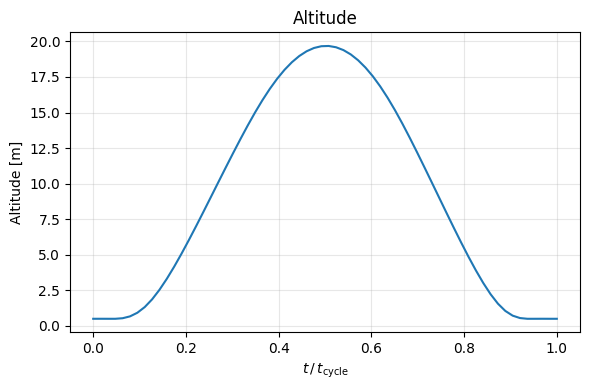

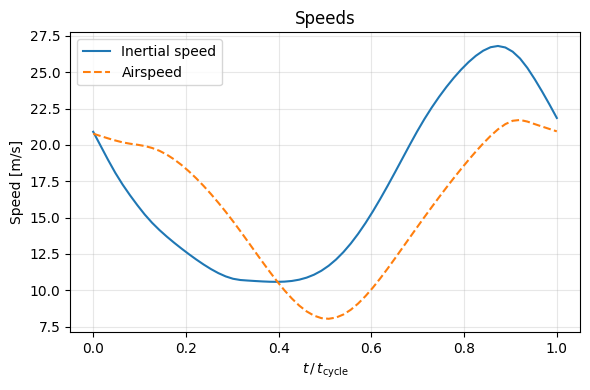

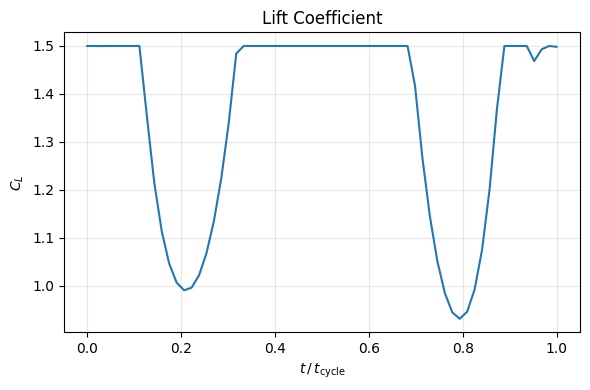

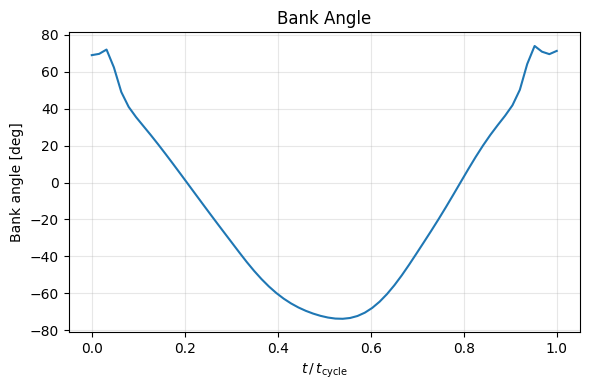

In [31]:
# Individual summary plots
t_cycle = sol.value(dt) * N
t_norm = np.linspace(0, 1, N)  # t / t_cycle

h_sol = sol.value(h)
cl_sol = sol.value(cl)
mu_sol = sol.value(mu)
speed_air = sol.value(V_a)
wind_speed = sol.value(V_w)
speed_inertial = np.sqrt(sol.value(u)**2 + sol.value(v)**2 + sol.value(w)**2)

# 1) Altitude
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_norm, h_sol)
ax.set_ylabel('Altitude [m]')
ax.set_title('Altitude')
ax.set_xlabel(r'$t\,/\,t_{\mathrm{cycle}}$')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('altitude.jpg', dpi=150, bbox_inches='tight')
plt.show()

# 2) Speeds
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_norm, speed_inertial, label='Inertial speed')
ax.plot(t_norm, speed_air, '--', label='Airspeed')
ax.set_ylabel('Speed [m/s]')
ax.set_title('Speeds')
ax.set_xlabel(r'$t\,/\,t_{\mathrm{cycle}}$')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('speeds.jpg', dpi=150, bbox_inches='tight')
plt.show()

# 3) Lift coefficient
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_norm, cl_sol)
ax.set_ylabel(r'$C_L$')
ax.set_title('Lift Coefficient')
ax.set_xlabel(r'$t\,/\,t_{\mathrm{cycle}}$')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lift_coefficient.jpg', dpi=150, bbox_inches='tight')
plt.show()

# 4) Bank angle
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_norm, np.degrees(mu_sol))
ax.set_ylabel('Bank angle [deg]')
ax.set_title('Bank Angle')
ax.set_xlabel(r'$t\,/\,t_{\mathrm{cycle}}$')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bank_angle.jpg', dpi=150, bbox_inches='tight')
plt.show()

All in all the results are very close to those found in Sachs (2005), except for that the bank angle is shown in the opposite direction. However, there are two 

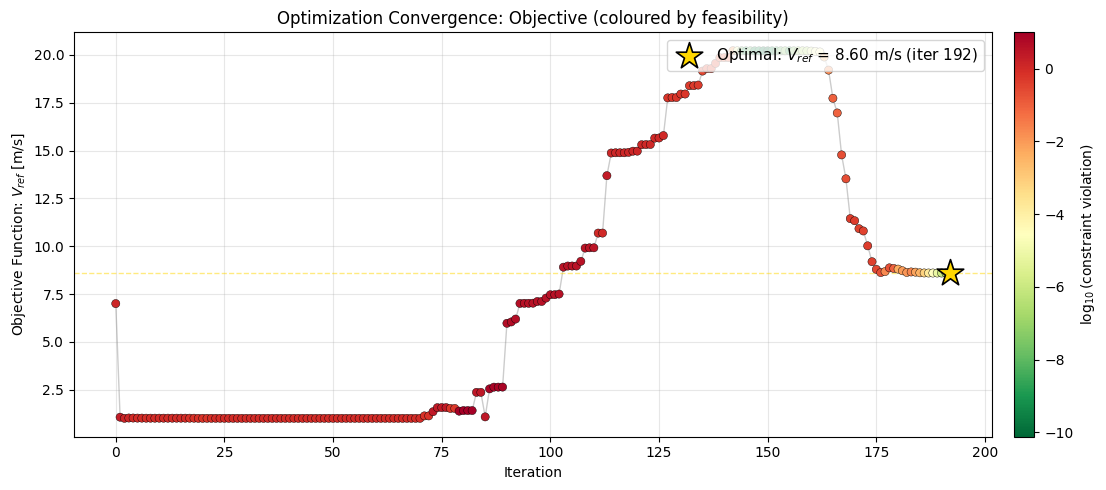

Total iterations: 193
Final objective: 8.598706
Final constraint violation: 4.16e-08


In [ ]:
import json

# Extract convergence history from the solver

# Get the stats from the optimizer
stats = opti.stats()

# CasAdi stores iterations as a dict of lists, not a list of dicts
iterations = stats['iterations']
objective_values = np.array(iterations['obj'])
constraint_violations = np.array(iterations['inf_pr'])

# Feasibility threshold (same as solver tolerance)
tol = opts.get('ipopt.tol', 1e-6)
feasible = constraint_violations <= tol
iters = np.arange(len(objective_values))

# Colour by log constraint violation (continuous gradient)
log_cv = np.log10(np.clip(constraint_violations, 1e-12, None))

# Plot convergence history
fig, ax = plt.subplots(figsize=(12, 5))

# Objective function over iterations — colour by constraint violation level
ax.plot(iters, objective_values, '-', color='grey', lw=1, alpha=0.4)
sc = ax.scatter(iters, objective_values, c=log_cv, cmap='RdYlGn_r',
                edgecolors='k', linewidths=0.3, s=35, zorder=3)

# Highlight the final (optimal) solution with a large star
final_idx = len(objective_values) - 1
ax.scatter(final_idx, objective_values[final_idx], marker='*', s=400,
           c='gold', edgecolors='black', linewidths=1.2, zorder=5,
           label=f'Optimal: $V_{{ref}}$ = {objective_values[final_idx]:.2f} m/s (iter {final_idx})')
ax.axhline(objective_values[final_idx], ls='--', color='gold', alpha=0.5, lw=1)

cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(r'$\log_{10}$(constraint violation)')
ax.set_ylabel('Objective Function: $V_{ref}$ [m/s]')
ax.set_xlabel('Iteration')
ax.set_title('Optimization Convergence: Objective (coloured by feasibility)')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
n_iters = len(objective_values)
print(f"Total iterations: {n_iters}")
print(f"Final objective: {objective_values[-1]:.6f}")

print(f"Final constraint violation: {constraint_violations[-1]:.2e}")

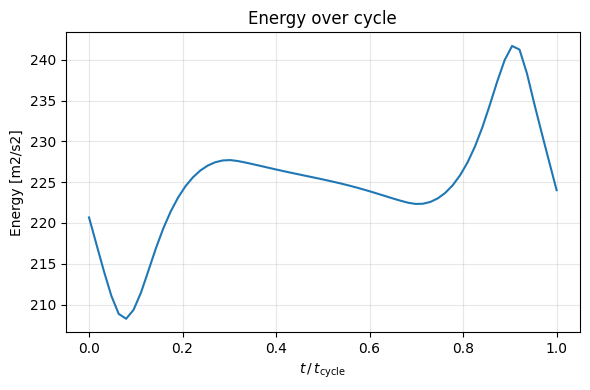

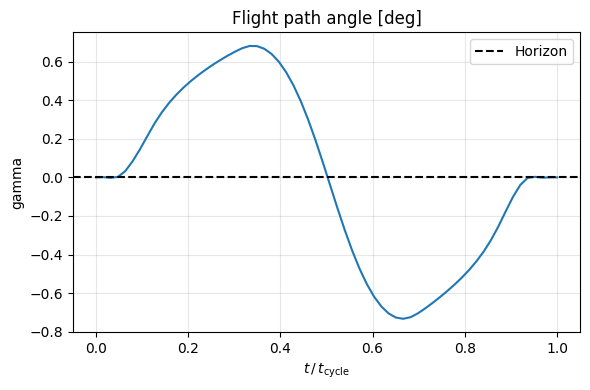

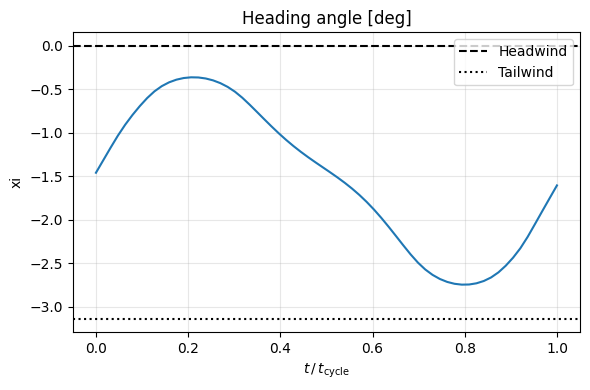

In [30]:
Va_sol = sol.value(V_a)
E_sol  = g * h_sol + 0.5 * Va_sol**2

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_norm, E_sol)
ax.set_ylabel('Energy [m2/s2]')
ax.set_title('Energy over cycle')
ax.set_xlabel(r'$t\,/\,t_{\mathrm{cycle}}$')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('energy.jpg', dpi=150, bbox_inches='tight')
plt.show()


fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_norm, sol.value(gamma))
ax.axhline(0.0, linestyle='--', color='black', label='Horizon')
ax.set_ylabel('gamma')
ax.set_title('Flight path angle [deg]')
ax.set_xlabel(r'$t\,/\,t_{\mathrm{cycle}}$')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('gamma.jpg', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_norm, sol.value(xi))
ax.axhline(0.0, linestyle='--', color='black', label='Headwind')
ax.axhline(-3.14, linestyle=':', color='black', label='Tailwind')
ax.set_ylabel('xi')
ax.set_title('Heading angle [deg]')
ax.set_xlabel(r'$t\,/\,t_{\mathrm{cycle}}$')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('xi.jpg', dpi=150, bbox_inches='tight')
plt.show()

## 3D orbit in reduced state space (h, γ, ξ)

The orbit is closed in $(u, v, w, h)$ by construction, so projecting it onto $(h, \gamma, \xi)$ should also form a closed loop — one traversal of the periodic soaring cycle visualised as a curve on the cylinder $\mathbb{R}^+ \times [-\pi/2, \pi/2] \times S^1$.

In [21]:
# Extract the reduced state variables for the optimal orbit
gamma_sol = sol.value(gamma)   # flight path angle [rad], positive = climbing
xi_sol    = sol.value(xi)      # heading angle [rad] relative to wind axis

# Close the loop: append first point so the curve connects back to start
h_loop     = np.append(h_sol,     h_sol[0])
gamma_loop = np.append(gamma_sol, gamma_sol[0])
xi_loop    = np.append(xi_sol,    xi_sol[0])

# Colour by altitude to show shear-layer exposure along the orbit
fig_state = go.Figure()

fig_state.add_trace(go.Scatter3d(
    x=np.degrees(xi_loop),
    y=np.degrees(gamma_loop),
    z=h_loop,
    mode='lines',
    line=dict(
        color=h_loop,
        colorscale='plasma',
        width=6,
        colorbar=dict(title='h [m]', len=0.5, thickness=15, x=1.0),
    ),
    name='Orbit',
    hovertemplate=(
        'ξ: %{x:.1f}°<br>'
        'γ: %{y:.1f}°<br>'
        'h: %{z:.2f} m<extra></extra>'
    ),
))

# Mark the start point
fig_state.add_trace(go.Scatter3d(
    x=[np.degrees(xi_sol[0])],
    y=[np.degrees(gamma_sol[0])],
    z=[h_sol[0]],
    mode='markers',
    marker=dict(size=7, color='lime', line=dict(color='black', width=1)),
    name='Start (h = 0.5 m)',
))

fig_state.update_layout(
    title=dict(
        text=(f'Dynamic soaring orbit in reduced state space<br>'
              f'<sup>V_ref = {sol.value(V_ref):.2f} m/s, '
              f'T_cycle = {sol.value(dt)*N:.2f} s</sup>'),
        x=0.5,
    ),
    scene=dict(
        xaxis_title='ξ — heading angle [°]',
        yaxis_title='γ — flight path angle [°]',
        zaxis_title='h — altitude [m]',
        aspectmode='auto',
        camera=dict(eye=dict(x=1.6, y=1.6, z=0.8)),
    ),
    width=820, height=680,
    margin=dict(l=0, r=80, t=60, b=0),
    legend=dict(x=0.0, y=1.0, bgcolor='rgba(255,255,255,0.7)'),
)

fig_state.show()

In [22]:
# 3D orbit in reduced state space (γ, ξ, E) — total specific energy on z-axis
# E = g*h + 0.5*V_a^2  [m²/s²]
Va_sol = sol.value(V_a)
E_sol  = g * h_sol + 0.5 * Va_sol**2

# Close the loop
gamma_loop = np.append(gamma_sol, gamma_sol[0])
xi_loop    = np.append(xi_sol,    xi_sol[0])
E_loop     = np.append(E_sol,     E_sol[0])

fig_E = go.Figure()

fig_E.add_trace(go.Scatter3d(
    x=np.degrees(xi_loop),
    y=np.degrees(gamma_loop),
    z=E_loop,
    mode='lines',
    line=dict(
        color=E_loop,
        colorscale='plasma',
        width=6,
        colorbar=dict(title='E [m²/s²]', len=0.5, thickness=15, x=1.0),
    ),
    name='Orbit',
    hovertemplate=(
        'ξ: %{x:.1f}°<br>'
        'γ: %{y:.1f}°<br>'
        'E: %{z:.1f} m²/s²<extra></extra>'
    ),
))

fig_E.add_trace(go.Scatter3d(
    x=[np.degrees(xi_sol[0])],
    y=[np.degrees(gamma_sol[0])],
    z=[E_sol[0]],
    mode='markers',
    marker=dict(size=7, color='lime', line=dict(color='black', width=1)),
    name='Start',
))

fig_E.update_layout(
    title=dict(
        text=(f'Dynamic soaring orbit in (ξ, γ, E) state space<br>'
              f'<sup>V_ref = {sol.value(V_ref):.2f} m/s, '
              f'T_cycle = {sol.value(dt)*N:.2f} s</sup>'),
        x=0.5,
    ),
    scene=dict(
        xaxis_title='ξ — heading angle [°]',
        yaxis_title='γ — flight path angle [°]',
        zaxis_title='E = gh + ½Vₐ² [m²/s²]',
        aspectmode='auto',
        camera=dict(eye=dict(x=1.6, y=1.6, z=0.8)),
    ),
    width=820, height=680,
    margin=dict(l=0, r=80, t=60, b=0),
    legend=dict(x=0.0, y=1.0, bgcolor='rgba(255,255,255,0.7)'),
)

fig_E.show()

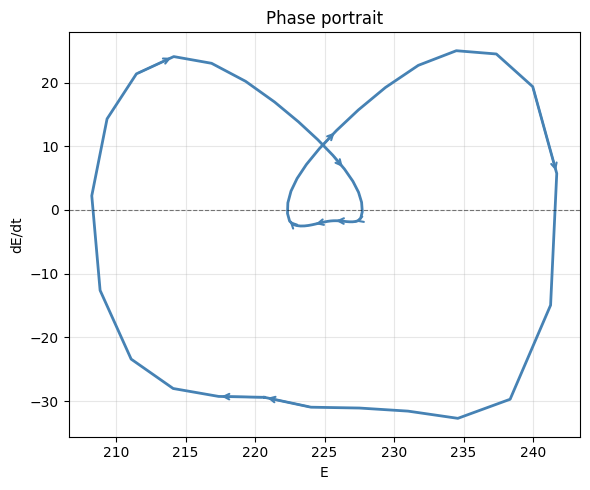

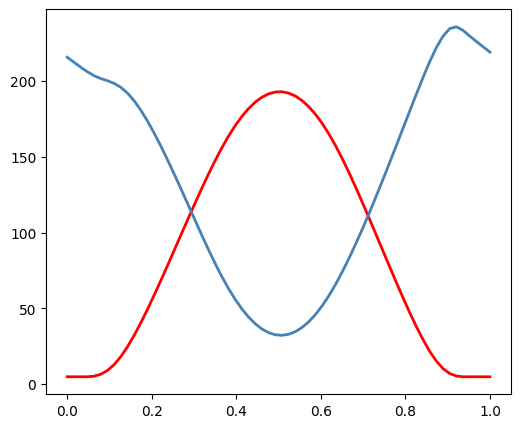

In [41]:
# Phase portrait: dE/dt vs E over one soaring cycle
dEdt = np.gradient(E_sol, dt_val)   # central differences (periodic BCs handled at endpoints)

# Close the loop so the curve connects back to start
E_phase    = np.append(E_sol, E_sol[0])
dEdt_phase = np.append(dEdt,  dEdt[0])

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(E_phase, dEdt_phase, lw=2, color='steelblue')

# Direction arrows spaced evenly around the orbit
n_arrows = 10
for i in np.linspace(0, N - 1, n_arrows, dtype=int):
    j = (i + 1) % N
    ax.annotate('',
                xy=(E_sol[j], dEdt[j]),
                xytext=(E_sol[i], dEdt[i]),
                arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.5))

ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('E')
ax.set_ylabel('dE/dt')
ax.set_title('Phase portrait')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


E_sol  = g * h_sol + 0.5 * Va_sol**2
pe = g*h_sol 
ke = 0.5 * Va_sol * Va_sol

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(t_norm, pe, lw=2, color='r')
ax.plot(t_norm, ke, lw=2, color='steelblue')
plt.show()



## Frenet-Serret Frame Analysis

The trajectory $\mathbf{r}(t) = (x, y, h)$ is a space curve. Its local geometry is captured by the **Frenet-Serret (TNB) frame**:

| Quantity | Meaning |
|---|---|
| **T** | Unit tangent — direction of travel |
| **N** | Principal normal — direction of curvature (centripetal) |
| **B = T × N** | Binormal — out-of-plane axis |
| $\kappa$ | Curvature — how sharply the path bends ($\kappa = 1/R$) |
| $\tau$ | Torsion — how fast the osculating plane rotates (sign = handedness) |

Derivatives $\mathbf{r}'', \mathbf{r}'''$ are computed via **central finite differences with periodic wrapping** (consistent with the trapezoidal collocation used by the optimiser).

> **Velocity sign convention:** `dh/dt = −w` (w is positive downward in the EoM), so $\mathbf{r}'(t) = (u,\, v,\, -w)$.

In [35]:
# Extract w_sol (not yet pulled from solution)
w_sol = sol.value(w)

# r′(t) = (u, v, −w) — inertial velocity in position space (N, 3)
r_dot = np.column_stack([u_sol, v_sol, -w_sol])
ds_dt = np.linalg.norm(r_dot, axis=1)   # arc-length speed |r′|
T_vec = r_dot / ds_dt[:, None]            # unit tangent (N, 3)

# r″ and r‴ via central finite differences with periodic wrapping
r_ddot  = (np.roll(r_dot,  -1, 0) - np.roll(r_dot,  1, 0)) / (2 * dt_val)
r_dddot = (np.roll(r_ddot, -1, 0) - np.roll(r_ddot, 1, 0)) / (2 * dt_val)

# Curvature  κ = |r′ × r″| / |r′|³
cross_12      = np.cross(r_dot, r_ddot)
cross_12_norm = np.linalg.norm(cross_12, axis=1)
kappa         = cross_12_norm / ds_dt**3

# Principal normal  N̂ = Ṫ / |Ṫ|
T_dot      = (np.roll(T_vec, -1, 0) - np.roll(T_vec, 1, 0)) / (2 * dt_val)
T_dot_norm = np.linalg.norm(T_dot, axis=1)
eps = 1e-8
N_vec = np.where(T_dot_norm[:, None] > eps, T_dot / T_dot_norm[:, None], 0.0)

# Binormal  B̂ = T̂ × N̂
B_vec = np.cross(T_vec, N_vec)

# Torsion  τ = (r′ × r″ · r‴) / |r′ × r″|²
tau = np.where(
    cross_12_norm**2 > eps**2,
    np.einsum('ij,ij->i', cross_12, r_dddot) / cross_12_norm**2,
    0.0,
)

print(f"Mean κ   = {kappa.mean():.4f} m⁻¹  (mean radius = {1/kappa.mean():.1f} m)")
print(f"Max  κ   = {kappa.max():.4f} m⁻¹  (min radius  = {1/kappa.max():.1f} m)")
print(f"Mean |τ| = {np.abs(tau).mean():.4f} m⁻¹")

Mean κ   = 0.0500 m⁻¹  (mean radius = 20.0 m)
Max  κ   = 0.0926 m⁻¹  (min radius  = 10.8 m)
Mean |τ| = 0.0629 m⁻¹


### Interpretation

- **$\kappa$ peaks** correspond to tight turns (low-altitude wingover at sea-surface and high-altitude reversal).
- **$\tau$ sign changes** indicate that the osculating plane rotates in opposite directions across the two halves of the orbit — the hallmark of a 3-D helical/figure-eight trajectory.
- A purely planar orbit would have $\tau \equiv 0$; non-zero torsion here reflects the altitude variation coupled with the lateral turns.

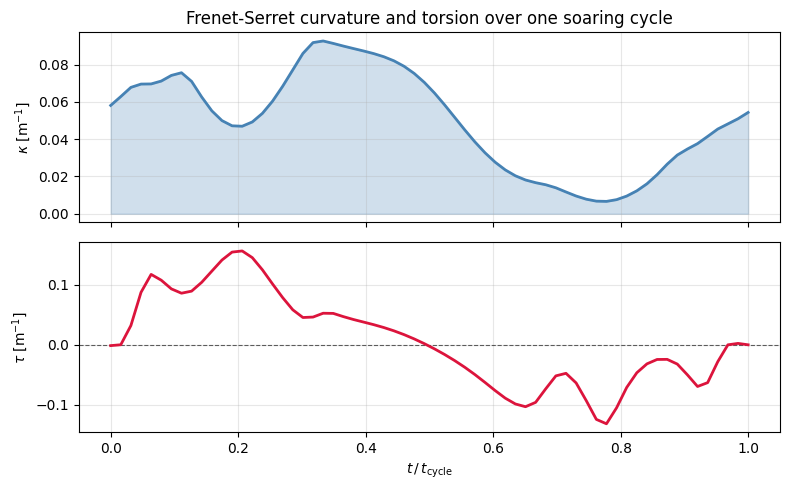

Saved frenet_kappa_tau.jpg


In [36]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

# --- Curvature ---
ax1.fill_between(t_norm, kappa, alpha=0.25, color='steelblue')
ax1.plot(t_norm, kappa, color='steelblue', lw=2)
ax1.set_ylabel(r'$\kappa$ [m$^{-1}$]')
ax1.set_title('Frenet-Serret curvature and torsion over one soaring cycle')
ax1.grid(True, alpha=0.3)

# --- Torsion ---
ax2.axhline(0, color='k', lw=0.8, ls='--', alpha=0.6)
ax2.plot(t_norm, tau, color='crimson', lw=2)
ax2.set_ylabel(r'$\tau$ [m$^{-1}$]')
ax2.set_xlabel(r'$t\,/\,t_{\mathrm{cycle}}$')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('frenet_kappa_tau.jpg', dpi=150, bbox_inches='tight')
plt.show()
print('Saved frenet_kappa_tau.jpg')

In [37]:
# Close the position loop for continuous line rendering
x_loop = np.append(x_sol, x_sol[0])
y_loop = np.append(y_sol, y_sol[0])
h_loop = np.append(h_sol, h_sol[0])
kappa_loop = np.append(kappa, kappa[0])
tau_loop   = np.append(tau,   tau[0])

# ── Figure 1: coloured by κ ──────────────────────────────────────────────────
fig_k = go.Figure()
fig_k.add_trace(go.Scatter3d(
    x=x_loop, y=y_loop, z=h_loop,
    mode='lines',
    line=dict(color=kappa_loop, colorscale='Viridis', width=6,
              colorbar=dict(title='κ [m⁻¹]', len=0.6, thickness=15, x=1.0)),
    name='κ',
    hovertemplate='x:%{x:.1f} y:%{y:.1f} h:%{z:.1f}<extra>κ=%{line.color:.4f}</extra>',
))

# TNB arrows at every 8th point (T=blue, N=green, B=red), scaled to 4 m
arrow_scale = 4.0
stride = 8
for i in range(0, N, stride):
    origin = np.array([x_sol[i], y_sol[i], h_sol[i]])
    for vec, col, lbl in [(T_vec[i], 'blue', 'T'),
                          (N_vec[i], 'green', 'N'),
                          (B_vec[i], 'red',   'B')]:
        tip = origin + arrow_scale * vec
        fig_k.add_trace(go.Scatter3d(
            x=[origin[0], tip[0]], y=[origin[1], tip[1]], z=[origin[2], tip[2]],
            mode='lines',
            line=dict(color=col, width=3),
            showlegend=(i == 0),
            name=lbl,
            hoverinfo='skip',
        ))

fig_k.update_layout(
    title='Trajectory coloured by curvature κ (with TNB frame arrows)',
    scene=dict(xaxis_title='x [m]', yaxis_title='y [m]', zaxis_title='h [m]',
               aspectmode='cube'),
    width=820, height=700,
    margin=dict(l=0, r=80, t=50, b=0),
)
fig_k.show()

# ── Figure 2: coloured by τ ──────────────────────────────────────────────────
tau_abs_max = float(np.abs(tau).max())
fig_t = go.Figure()
fig_t.add_trace(go.Scatter3d(
    x=x_loop, y=y_loop, z=h_loop,
    mode='lines',
    line=dict(color=tau_loop, colorscale='RdBu', width=6,
              cmin=-tau_abs_max, cmax=tau_abs_max,
              colorbar=dict(title='τ [m⁻¹]', len=0.6, thickness=15, x=1.0)),
    name='τ',
    hovertemplate='x:%{x:.1f} y:%{y:.1f} h:%{z:.1f}<extra>τ=%{line.color:.4f}</extra>',
))
fig_t.update_layout(
    title='Trajectory coloured by torsion τ (diverging scale, centred at 0)',
    scene=dict(xaxis_title='x [m]', yaxis_title='y [m]', zaxis_title='h [m]',
               aspectmode='cube'),
    width=820, height=700,
    margin=dict(l=0, r=80, t=50, b=0),
)
fig_t.show()

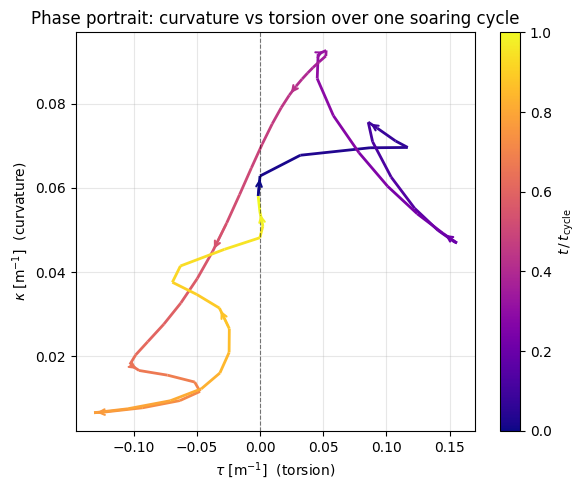

Saved frenet_phase_portrait.jpg


In [38]:
# Close the loop
kappa_ph = np.append(kappa, kappa[0])
tau_ph   = np.append(tau,   tau[0])
tnorm_ph = np.append(t_norm, 1.0)

fig, ax = plt.subplots(figsize=(6, 5))

# Colour segments by normalised time
from matplotlib.collections import LineCollection
import matplotlib.cm as cm

points = np.array([tau_ph, kappa_ph]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap='plasma', norm=plt.Normalize(0, 1))
lc.set_array(tnorm_ph[:-1])
lc.set_linewidth(2)
ax.add_collection(lc)
plt.colorbar(lc, ax=ax, label=r'$t\,/\,t_{\mathrm{cycle}}$')

# Direction arrows spaced evenly around the orbit
n_arrows = 10
arrow_idx = np.linspace(0, N - 2, n_arrows, dtype=int)
for i in arrow_idx:
    ax.annotate(
        '', xy=(tau_ph[i+1], kappa_ph[i+1]),
        xytext=(tau_ph[i], kappa_ph[i]),
        arrowprops=dict(arrowstyle='->', color=cm.plasma(tnorm_ph[i]), lw=1.5),
    )

ax.set_xlabel(r'$\tau$ [m$^{-1}$]  (torsion)')
ax.set_ylabel(r'$\kappa$ [m$^{-1}$]  (curvature)')
ax.set_title('Phase portrait: curvature vs torsion over one soaring cycle')
ax.axvline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.autoscale()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('frenet_phase_portrait.jpg', dpi=150, bbox_inches='tight')
plt.show()
print('Saved frenet_phase_portrait.jpg')